In [1]:
###day 4 summery

# Cell 1 — Imports and load data
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_style("darkgrid")

df = pd.read_csv('../data/creditcard.csv')

print("✅ Data loaded!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

✅ Data loaded!
Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [2]:
# Cell 2 — Create hour feature
# Time column = seconds since first transaction
# Dividing by 3600 converts to hours
# % 24 wraps it to 0-23 range

df['hour'] = (df['Time'] // 3600) % 24

print("Hour feature created!")
print("\nSample values:")
print(df[['Time', 'hour']].head(10))
print("\nHour range:", df['hour'].min(), "to", df['hour'].max())

Hour feature created!

Sample values:
   Time  hour
0   0.0   0.0
1   0.0   0.0
2   1.0   0.0
3   1.0   0.0
4   2.0   0.0
5   2.0   0.0
6   4.0   0.0
7   7.0   0.0
8   7.0   0.0
9   9.0   0.0

Hour range: 0.0 to 23.0


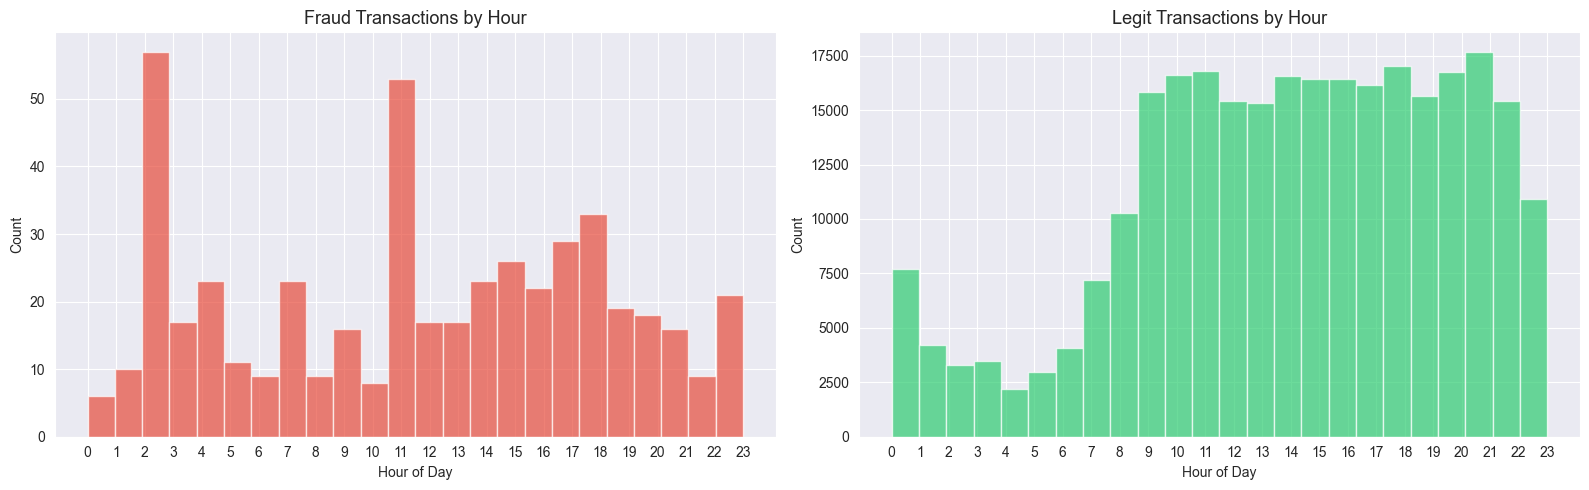

✅ Hour feature verified!


In [3]:
# Cell 3 — Verify hour feature makes sense
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

# Fraud by hour
axes[0].hist(fraud['hour'], bins=24, color='#e74c3c', alpha=0.7)
axes[0].set_title('Fraud Transactions by Hour', fontsize=13)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(0, 24))

# Legit by hour
axes[1].hist(legit['hour'], bins=24, color='#2ecc71', alpha=0.7)
axes[1].set_title('Legit Transactions by Hour', fontsize=13)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('../data/hour_feature.png')
plt.show()

print("✅ Hour feature verified!")

In [4]:
# Cell 4 — Create log amount feature
# Adding 1 avoids log(0) which is undefined
df['amount_log'] = np.log(df['Amount'] + 1)

print("amount_log feature created!")
print("\nOriginal Amount stats:")
print(df['Amount'].describe())
print("\nLog Amount stats:")
print(df['amount_log'].describe())

amount_log feature created!

Original Amount stats:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Log Amount stats:
count    284807.000000
mean          3.152188
std           1.656648
min           0.000000
25%           1.887070
50%           3.135494
75%           4.358822
max          10.153941
Name: amount_log, dtype: float64


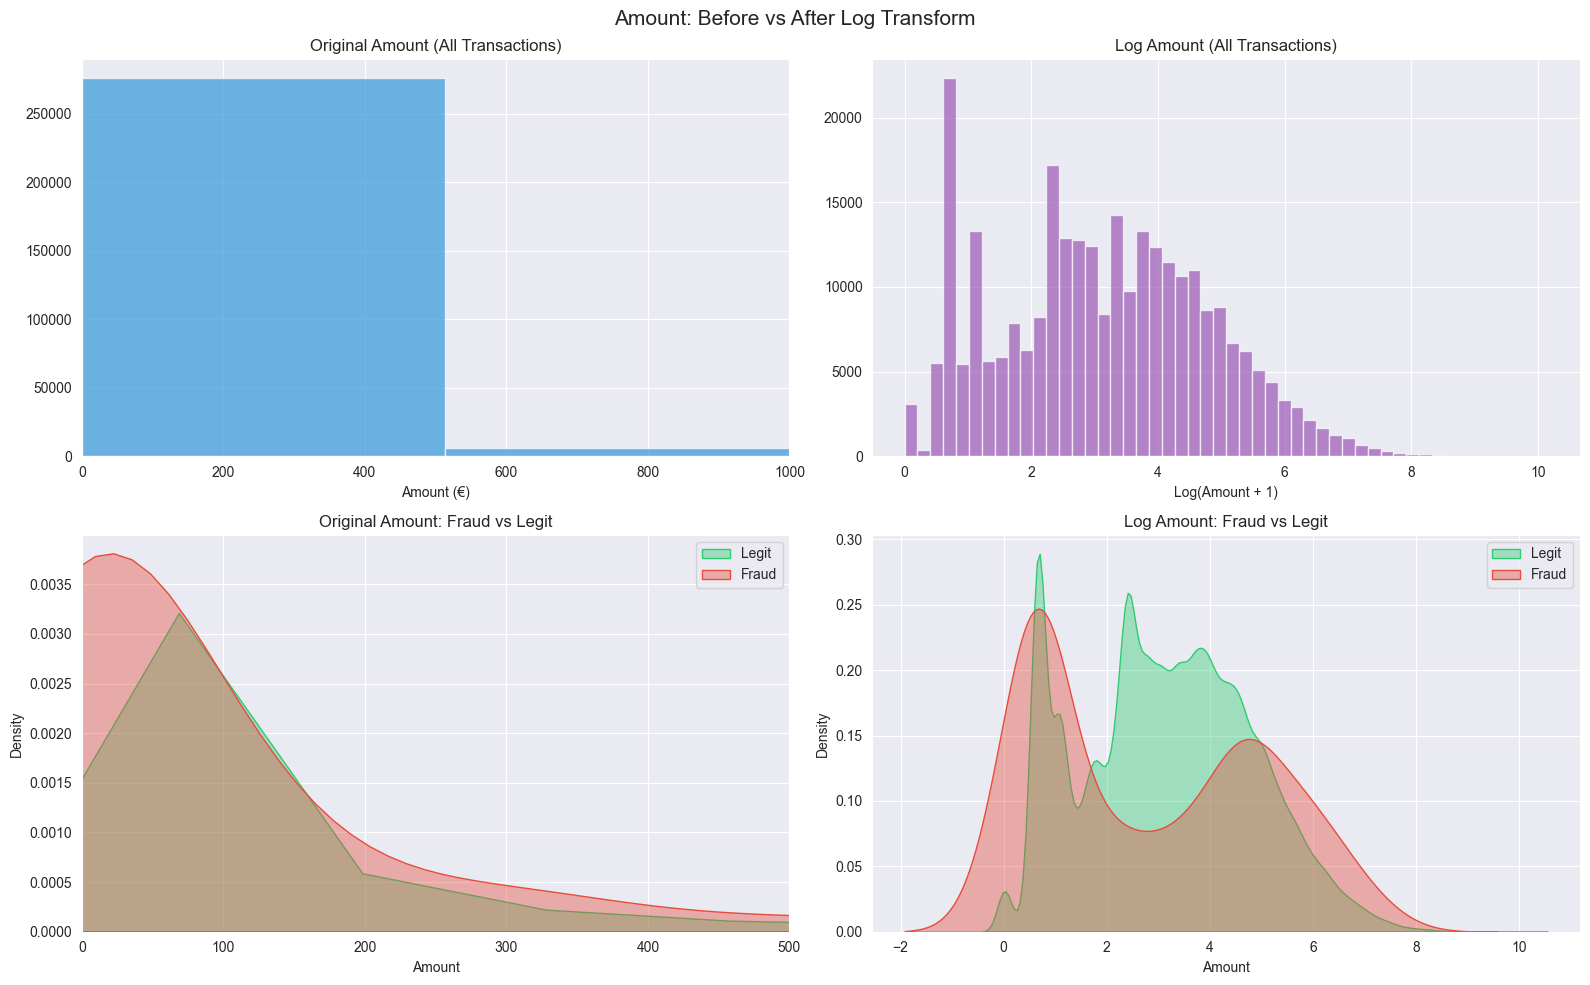

In [5]:
# Cell 5 — Visualize before and after log transform
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original amount - all transactions
axes[0][0].hist(df['Amount'], bins=50, color='#3498db', alpha=0.7)
axes[0][0].set_title('Original Amount (All Transactions)', fontsize=12)
axes[0][0].set_xlabel('Amount (€)')
axes[0][0].set_xlim([0, 1000])

# Log amount - all transactions
axes[0][1].hist(df['amount_log'], bins=50, color='#9b59b6', alpha=0.7)
axes[0][1].set_title('Log Amount (All Transactions)', fontsize=12)
axes[0][1].set_xlabel('Log(Amount + 1)')

# Original amount - fraud vs legit
sns.kdeplot(data=legit['Amount'], ax=axes[1][0],
            label='Legit', color='#2ecc71', fill=True, alpha=0.4)
sns.kdeplot(data=fraud['Amount'], ax=axes[1][0],
            label='Fraud', color='#e74c3c', fill=True, alpha=0.4)
axes[1][0].set_title('Original Amount: Fraud vs Legit', fontsize=12)
axes[1][0].set_xlim([0, 500])
axes[1][0].legend()

# Log amount - fraud vs legit
sns.kdeplot(data=np.log(legit['Amount'] + 1), ax=axes[1][1],
            label='Legit', color='#2ecc71', fill=True, alpha=0.4)
sns.kdeplot(data=np.log(fraud['Amount'] + 1), ax=axes[1][1],
            label='Fraud', color='#e74c3c', fill=True, alpha=0.4)
axes[1][1].set_title('Log Amount: Fraud vs Legit', fontsize=12)
axes[1][1].legend()

plt.suptitle('Amount: Before vs After Log Transform', fontsize=15)
plt.tight_layout()
plt.savefig('../data/log_transform_comparison.png')
plt.show()

In [6]:
# Cell 6 — Scale Amount and hour
scaler_amount = StandardScaler()
scaler_hour = StandardScaler()

df['amount_scaled'] = scaler_amount.fit_transform(df[['Amount']])
df['hour_scaled'] = scaler_hour.fit_transform(df[['hour']])

print("Scaling complete!")
print("\nAmount scaled stats:")
print(df['amount_scaled'].describe())
print("\nHour scaled stats:")
print(df['hour_scaled'].describe())

Scaling complete!

Amount scaled stats:
count    2.848070e+05
mean     2.913952e-17
std      1.000002e+00
min     -3.532294e-01
25%     -3.308401e-01
50%     -2.652715e-01
75%     -4.471707e-02
max      1.023622e+02
Name: amount_scaled, dtype: float64

Hour scaled stats:
count    2.848070e+05
mean     8.941442e-17
std      1.000002e+00
min     -2.406930e+00
25%     -6.933821e-01
50%      1.633919e-01
75%      8.488112e-01
max      1.534230e+00
Name: hour_scaled, dtype: float64


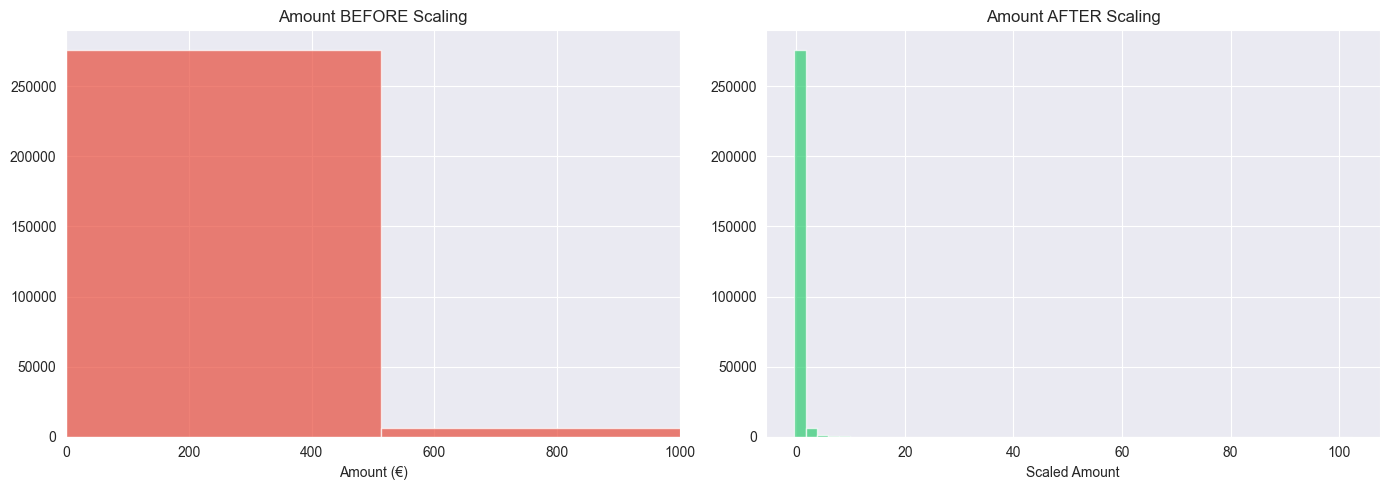

✅ Scaling verified — values now centered around 0


In [7]:
# Cell 7 — Verify scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount before and after scaling
axes[0].hist(df['Amount'], bins=50, color='#e74c3c', alpha=0.7)
axes[0].set_title('Amount BEFORE Scaling', fontsize=12)
axes[0].set_xlabel('Amount (€)')
axes[0].set_xlim([0, 1000])

axes[1].hist(df['amount_scaled'], bins=50, color='#2ecc71', alpha=0.7)
axes[1].set_title('Amount AFTER Scaling', fontsize=12)
axes[1].set_xlabel('Scaled Amount')

plt.tight_layout()
plt.savefig('../data/scaling_comparison.png')
plt.show()

print("✅ Scaling verified — values now centered around 0")

In [8]:
# Cell 8 — Drop original Time and Amount columns
print("Columns BEFORE dropping:", df.shape[1])

df.drop(['Time', 'Amount'], axis=1, inplace=True)

print("Columns AFTER dropping:", df.shape[1])
print("\nFinal columns:")
print(df.columns.tolist())

Columns BEFORE dropping: 35
Columns AFTER dropping: 33

Final columns:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'hour', 'amount_log', 'amount_scaled', 'hour_scaled']


In [9]:
# Cell 9 — Check all features are ready
print("=== FINAL FEATURE SUMMARY ===")
print(f"\nTotal features: {df.shape[1] - 1}")
print(f"Target column: Class")
print(f"\nShape: {df.shape}")

print("\n=== NULL CHECK ===")
print(df.isnull().sum().sum(), "null values found")

print("\n=== FEATURE STATS ===")
df.describe()

=== FINAL FEATURE SUMMARY ===

Total features: 32
Target column: Class

Shape: (284807, 33)

=== NULL CHECK ===
0 null values found

=== FEATURE STATS ===


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,Class,hour,amount_log,amount_scaled,hour_scaled
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000,284807.000000,2.848070e+05,2.848070e+05
mean,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,...,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,0.001727,14.046470,3.152188,2.913952e-17,8.941442e-17
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,...,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,0.041527,5.835854,1.656648,1.000002e+00,1.000002e+00
min,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,...,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000,0.000000,-3.532294e-01,-2.406930e+00
25%,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,...,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,0.000000,10.000000,1.887070,-3.308401e-01,-6.933821e-01
50%,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,...,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,0.000000,15.000000,3.135494,-2.652715e-01,1.633919e-01
75%,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,...,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,0.000000,19.000000,4.358822,-4.471707e-02,8.488112e-01
max,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,...,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,1.000000,23.000000,10.153941,1.023622e+02,1.534230e+00


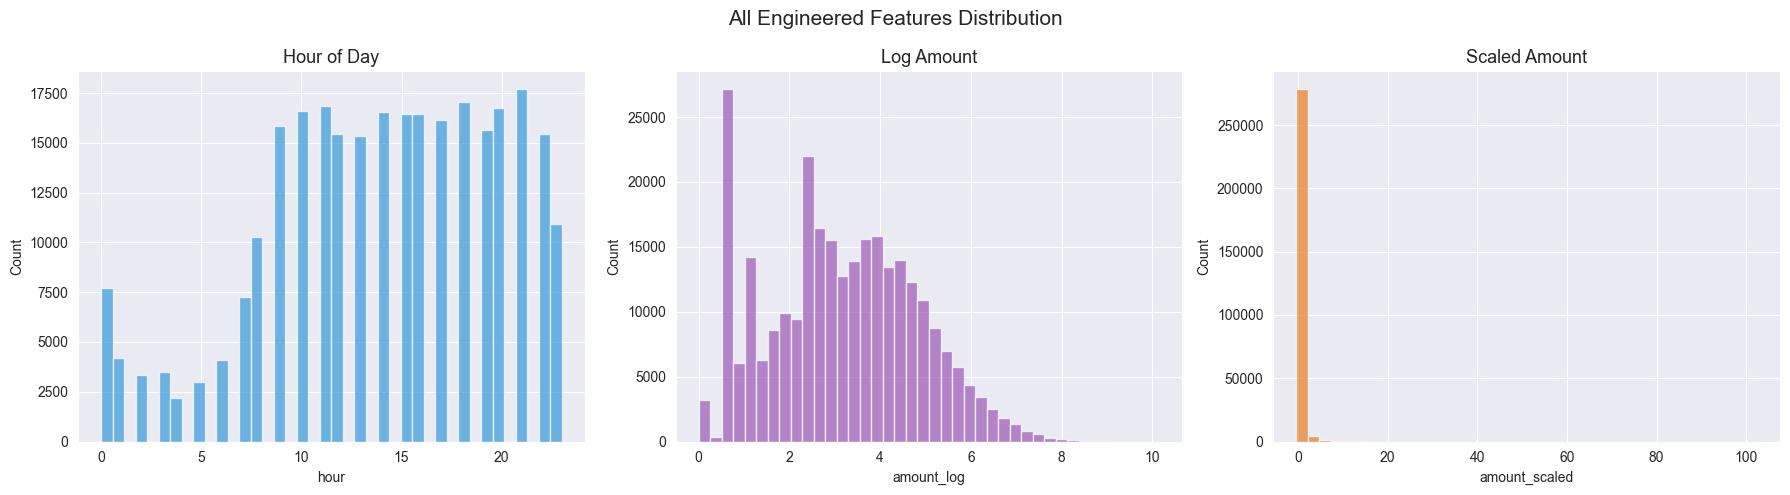

In [10]:
# Cell 10 — Visualize all engineered features together
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features_to_check = ['hour', 'amount_log', 'amount_scaled']
colors = ['#3498db', '#9b59b6', '#e67e22']
titles = ['Hour of Day', 'Log Amount', 'Scaled Amount']

for i, (feat, color, title) in enumerate(
        zip(features_to_check, colors, titles)):
    axes[i].hist(df[feat], bins=40, color=color, alpha=0.7)
    axes[i].set_title(title, fontsize=13)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.suptitle('All Engineered Features Distribution', fontsize=15)
plt.tight_layout()
plt.savefig('../data/engineered_features.png')
plt.show()

In [11]:
# Cell 11 — Save processed dataframe
df.to_csv('../data/creditcard_processed.csv', index=False)

print("✅ Processed dataset saved!")
print("File: data/creditcard_processed.csv")
print("Shape:", df.shape)
print("\nThis file will be used for all future steps")

✅ Processed dataset saved!
File: data/creditcard_processed.csv
Shape: (284807, 33)

This file will be used for all future steps


In [12]:
# Cell 12 — Save scalers for deployment later
import pickle
import os

os.makedirs('../models', exist_ok=True)

with open('../models/scaler_amount.pkl', 'wb') as f:
    pickle.dump(scaler_amount, f)

with open('../models/scaler_hour.pkl', 'wb') as f:
    pickle.dump(scaler_hour, f)

print("✅ Scalers saved to models/ folder!")
print("These will be used in FastAPI deployment on Day 15")

✅ Scalers saved to models/ folder!
These will be used in FastAPI deployment on Day 15
